<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_3_AUTOENCODER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Librerías principales para el modelo de aprendizaje profundo
import tensorflow as tf          # Para construir y entrenar la red neuronal
import numpy as np              # Para manejo de datos numéricos
import matplotlib.pyplot as plt # Para visualizar imágenes y resultados
import os                       # Para manejar rutas de archivos

# Parámetros del modelo
IMG_SIZE = 256   # Tamaño al que se redimensionan las imágenes (256x256)
BATCH_SIZE = 2   # Número de imágenes procesadas en cada paso de entrenamiento (pequeño por memoria)
EPOCHS = 10      # Número de veces que el modelo recorre el dataset completo

In [25]:
# Función para cargar imágenes usando OpenCV
def load_image_cv2(noisy_path, clean_path):
    import cv2  # Se importa aquí porque tf.py_function lo necesita en su contexto

    # Convertir rutas de tensor a string
    noisy_path = noisy_path.numpy().decode('utf-8')
    clean_path = clean_path.numpy().decode('utf-8')

    # Leer imagen ruidosa en escala de grises
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    noisy = cv2.resize(noisy, (IMG_SIZE, IMG_SIZE))  # Redimensionar
    noisy = noisy.astype(np.float32) / 255.0         # Normalizar [0,1]
    noisy = np.expand_dims(noisy, axis=-1)           # Añadir canal

    # Leer imagen limpia (ground truth)
    clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    clean = cv2.resize(clean, (IMG_SIZE, IMG_SIZE))
    clean = clean.astype(np.float32) / 255.0
    clean = np.expand_dims(clean, axis=-1)

    return noisy, clean

    # Función que conecta OpenCV con TensorFlow
def parse_function(noisy_path, clean_path):
    noisy, clean = tf.py_function(
        load_image_cv2,                 # Función que carga imágenes
        [noisy_path, clean_path],       # Entradas
        [tf.float32, tf.float32]        # Tipos de salida
    )

    # Definir tamaño fijo (importante para el modelo)
    noisy.set_shape([IMG_SIZE, IMG_SIZE, 1])
    clean.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return noisy, clean

    # Función para crear el dataset completo
def create_dataset(noisy_dir, clean_dir):
    # Obtener lista de archivos
    noisy_files = sorted(os.listdir(noisy_dir))
    clean_files = sorted(os.listdir(clean_dir))

    # Crear rutas completas
    noisy_paths = [os.path.join(noisy_dir, f) for f in noisy_files]
    clean_paths = [os.path.join(clean_dir, f) for f in clean_files]

    # Crear dataset de TensorFlow
    dataset = tf.data.Dataset.from_tensor_slices((noisy_paths, clean_paths))

    # Aplicar función de carga
    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)

    # Agrupar en batches y optimizar lectura
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [30]:
# Conectar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

# Crear dataset de entrenamiento (imágenes ruidosas y ground truth)
train_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth"
)

# Crear dataset de validación
val_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy_val",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth_val"
)

# Usar solo una parte del dataset para reducir uso de memoria
train_ds = train_ds.take(100)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from tensorflow.keras import layers, models

# Función para construir el autoencoder
def build_autoencoder():

    # Entrada: imagen en escala de grises (256x256x1)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # 🔽 ENCODER (comprime la información)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)  # Reduce tamaño

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)  # Reduce más

    # 🔼 DECODER (reconstruye la imagen)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)

    # Salida: imagen reconstruida
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    # Crear modelo
    model = models.Model(inputs, outputs)

    # Compilar modelo
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# Crear el autoencoder
autoencoder = build_autoencoder()

# Mostrar estructura del modelo
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 128, 128, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 256, 256, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 256, 256, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Entrenamiento del autoencoder
history_ae = autoencoder.fit(
    train_ds,            # Datos de entrenamiento (imágenes ruidosas y limpias)
    validation_data=val_ds,  # Datos de validación para evaluar el modelo
    epochs=EPOCHS        # Número de iteraciones completas sobre el dataset
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 706ms/step - loss: 0.6471 - val_loss: 0.6674
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 719ms/step - loss: 0.5605 - val_loss: 0.6487
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 617ms/step - loss: 0.5439 - val_loss: 0.6453
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 616ms/step - loss: 0.5417 - val_loss: 0.6374
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 573ms/step - loss: 0.5406 - val_loss: 0.6337
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 624ms/step - loss: 0.5402 - val_loss: 0.6323
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 574ms/step - loss: 0.5399 - val_loss: 0.6305
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 622ms/step - loss: 0.5396 - val_loss: 0.6296
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 607ms/step - loss: 0.5392 - val_loss: 0.6294
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 608ms/step - loss: 0.5386 - val_loss: 0.6288


In [33]:
# Función para calcular métricas de calidad de imagen
def compute_metrics(y_true, y_pred):
    # PSNR: mide la calidad de reconstrucción (más alto = mejor)
    psnr = tf.image.psnr(y_true, y_pred, max_val=1.0)

    # SSIM: mide similitud estructural (más cercano a 1 = mejor)
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)

    # Promedio de las métricas
    return psnr.numpy().mean(), ssim.numpy().mean()


# Función para calcular ENL (Equivalent Number of Looks)
def enl(image):
    mean = np.mean(image)   # Promedio de la imagen
    var = np.var(image)     # Varianza

    # ENL: mide nivel de ruido (más alto = menos speckle)
    return (mean**2) / var

In [34]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_ae = autoencoder.predict(noisy)  # Predicción del autoencoder

# Calcular métricas entre la imagen real y la reconstruida
psnr_ae, ssim_ae = compute_metrics(clean, preds_ae)

# Mostrar resultados
print("AE → PSNR:", psnr_ae)
print("AE → SSIM:", ssim_ae)
print("AE → ENL:", enl(preds_ae[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
AE → PSNR: 27.408924
AE → SSIM: 0.35487914
AE → ENL: 0.22772317


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step


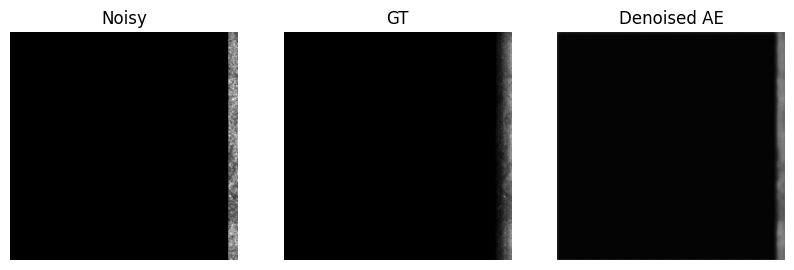

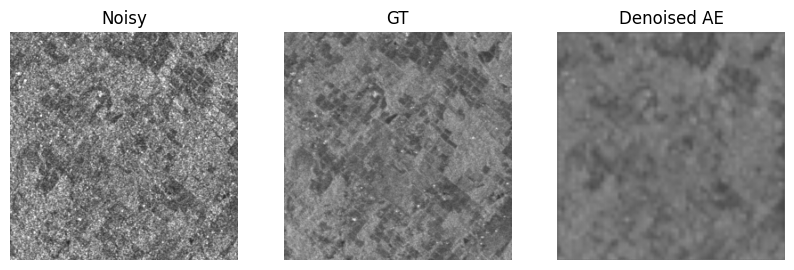

In [52]:

for noisy, clean in val_ds.take(1):
    preds = autoencoder.predict(noisy)

for i in range(len(noisy)):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(noisy[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(clean[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("GT")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Denoised AE")
    plt.axis('off')

    plt.show()

In [36]:
# Construcción del modelo U-Net
def build_unet():

    # Entrada: imagen en escala de grises
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    # 🔽 ENCODER (captura contexto)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)  # Reduce tamaño

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # 🔸 BOTTLENECK (representación profunda)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # 🔼 DECODER (reconstrucción)
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])  # 🔥 skip connection
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])  # 🔥 skip connection
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    # Salida final
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    # Crear modelo
    model = models.Model(inputs, outputs)

    # Compilar modelo
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# Crear modelo U-Net
unet = build_unet()

# Mostrar estructura
unet.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 128, 128,  │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_17[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │         33 │ conv2d_19[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,041 (902.50 KB)

 Trainable params: 231,041 (902.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Entrenamiento del modelo U-Net
history_unet = unet.fit(
    train_ds,             # Datos de entrenamiento (noisy → clean)
    validation_data=val_ds,  # Datos de validación para evaluar desempeño
    epochs=EPOCHS         # Número de épocas
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - loss: 0.6169 - val_loss: 0.6584
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - loss: 0.5484 - val_loss: 0.6440
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - loss: 0.5424 - val_loss: 0.6382
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - loss: 0.5406 - val_loss: 0.6372
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - loss: 0.5404 - val_loss: 0.6335
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - loss: 0.5398 - val_loss: 0.6337
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - loss: 0.5397 - val_loss: 0.6344
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - loss: 0.5378 - val_loss: 0.6287
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - loss: 0.5385 - val_loss: 0.6321
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - loss: 0.5382 - val_loss: 0.6313


In [38]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_unet = unet.predict(noisy)  # Predicción del U-Net

# Calcular métricas
psnr_unet, ssim_unet = compute_metrics(clean, preds_unet)

# Mostrar resultados
print("U-Net → PSNR:", psnr_unet)
print("U-Net → SSIM:", ssim_unet)
print("U-Net → ENL:", enl(preds_unet[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
U-Net → PSNR: 30.21558
U-Net → SSIM: 0.8015317
U-Net → ENL: 0.05786538


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


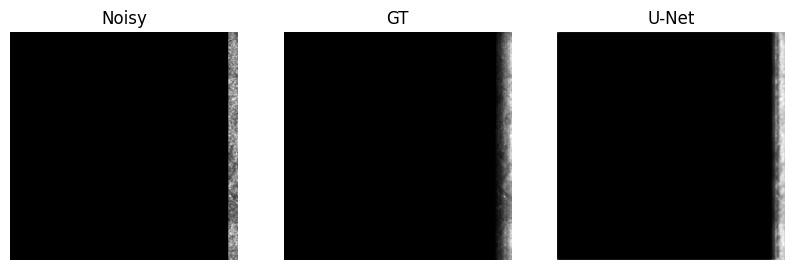

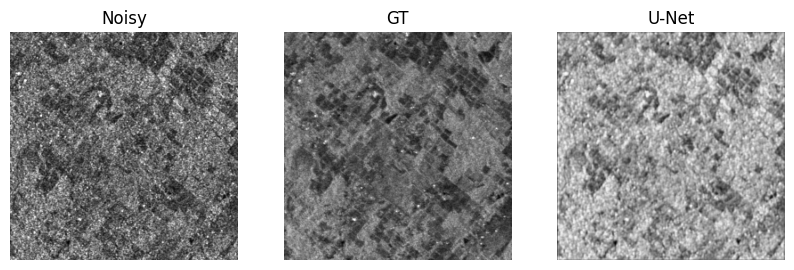

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


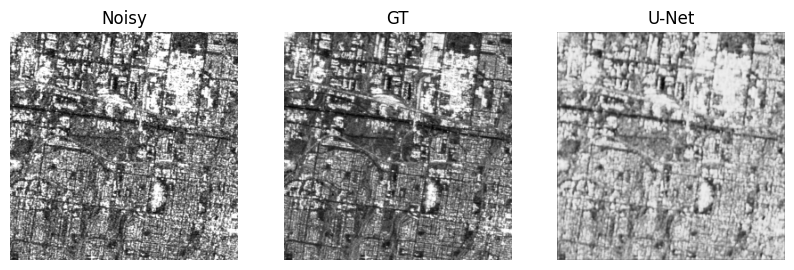

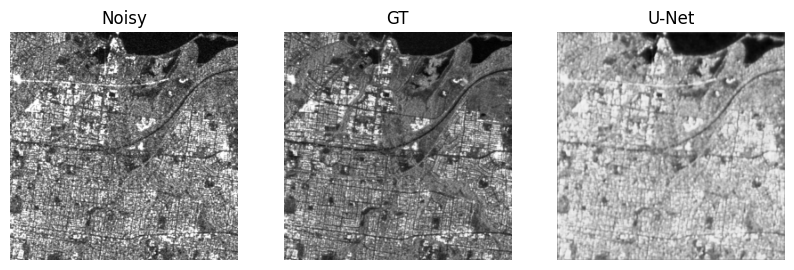

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step


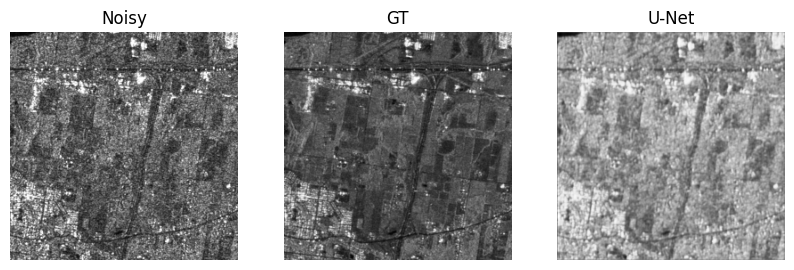

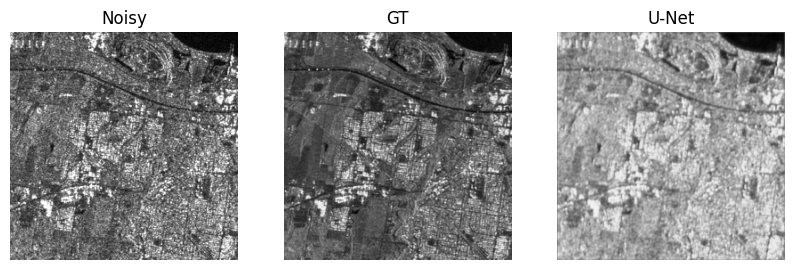

In [47]:
# Visualizar varias imágenes del conjunto de validación
for noisy, clean in val_ds.take(3):  # Tomar 3 batches
    preds = unet.predict(noisy)      # Predicción del modelo

    for i in range(len(noisy)):  # Recorrer imágenes del batch
        plt.figure(figsize=(10,3))

        # Imagen ruidosa (entrada)
        plt.subplot(1,3,1)
        plt.imshow(noisy[i].numpy().squeeze(), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Imagen original (ground truth)
        plt.subplot(1,3,2)
        plt.imshow(clean[i].numpy().squeeze(), cmap='gray')
        plt.title("GT")
        plt.axis('off')

        # Imagen reconstruida por U-Net
        plt.subplot(1,3,3)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.title("U-Net")
        plt.axis('off')

        plt.show()

In [39]:
# Mostrar resultados finales de ambos modelos
print("\n--- RESULTADOS ---")

# Métricas del autoencoder
print("Autoencoder → PSNR:", psnr_ae, "| SSIM:", ssim_ae)

# Métricas del U-Net
print("U-Net       → PSNR:", psnr_unet, "| SSIM:", ssim_unet)


--- RESULTADOS ---
Autoencoder → PSNR: 27.408924 | SSIM: 0.35487914
U-Net       → PSNR: 30.21558 | SSIM: 0.8015317
